# Comprensión del Problema

*(a)*. Variable objetivo: `valor_mercado_eur_TARGET`.

*(b)*. Tipo de regresión: Se trata de una Regresión Múltiple.

    El objetivo es predecir una variable numérica continua (el precio en euros) a partir de un conjunto diverso de variables predictoras (numéricas, discretas y categóricas).


In [ ]:
# Importar las librerías necesarias
import pandas as pd
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer

In [3]:
# ==============================================================================
# 0. Cargar los datos desde SQLite (¡La solución a tu error!)
# ==============================================================================
# Ajusta esta ruta si tu notebook actual está en una carpeta diferente
ruta_db = "../database/proyecto_analitica.db" 
conn = sqlite3.connect(ruta_db)
df = pd.read_sql_query("SELECT * FROM jugadores", conn)
conn.close()

# ==============================================================================
# a. Separar variables predictoras (X) y objetivo (y)
# ==============================================================================
# Eliminamos el target y las variables identificadoras que no son predictoras
columnas_a_eliminar = ['valor_mercado_eur_TARGET', 'id_observacion', 'player_id', 'fecha_valoracion']
X = df.drop(columns=columnas_a_eliminar) # 
y = df['valor_mercado_eur_TARGET'] # [cite: 36]

# ==============================================================================
# b. Dividir los datos: Train (70 %) y Test (30 %)
# ==============================================================================
# El random_state garantiza que la partición sea reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# ==============================================================================
# c. Construcción del Pipeline y Preprocesamiento
# ==============================================================================

# 1. Definir listas de columnas por tipo
num_cols = ['edad_al_momento', 'mes_de_nacimiento', 'altura_cm', 'minutos_jugados_12m',
            'partidos_jugados_12m', 'goles_12m', 'asistencias_12m', 'tarjetas_amarillas_12m',
            'tarjetas_rojas_12m', 'participacion_goles_p90', 'partidos_seleccion_12m',
            'convocatorias_historicas_seleccion', 'dias_para_fin_contrato', 
            'valor_maximo_historico_previo'] # [cite: 35]

cat_cols = ['pie_habil', 'posicion_principal', 'nacionalidad', 'liga_actual'] # [cite: 35]

# 2. Pipeline para Variables Numéricas
# Usamos KNNImputer porque la mediana distorsionaba la varianza de tus datos
num_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)), # 
    ('scaler', StandardScaler()) # Estandarización (media 0, varianza 1)
])

# 3. Pipeline para Variables Categóricas
# Usamos 'Sin Equipo' para no inflar los valores imputando con la moda
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Sin Equipo')), # 
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 4. Ensamblar todo con ColumnTransformer
# Esto aplica las transformaciones correspondientes solo a las columnas indicadas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

print(" Datos divididos y Preprocesador (Pipeline) configurado con éxito.")
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")

 Datos divididos y Preprocesador (Pipeline) configurado con éxito.
Dimensiones de X_train: (100833, 18)
Dimensiones de X_test: (43215, 18)


In [3]:
# Importaciones necesarias
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd
from IPython.display import display
import time
import joblib
import warnings

warnings.filterwarnings('ignore') # Para evitar mensajes rojos molestos

# ==============================================================================
# 3, 4 y 5. Entrenamiento, CV y Comparación (UNIFICADO Y SEGURO PARA LA RAM)
# ==============================================================================
print("Iniciando Entrenamiento y Validación Cruzada (k=5)... ¡Paciencia!\n")
start_time = time.time()

# 1. Definimos el diccionario con TODOS los modelos solicitados
# NOTA: Aplicamos n_jobs=2 y max_depth a los modelos complejos para evitar que la PC se congele
modelos = {
    'Regresión Lineal': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'LASSO': Lasso(alpha=0.1),
    'Árbol de Decisión': DecisionTreeRegressor(random_state=42, max_depth=15),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=2, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=10, n_jobs=2, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=15, n_jobs=2, random_state=42, verbose=-1)
}

pipelines_entrenados = {}
resultados_cv = []

# Métricas solicitadas
metricas = {
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error',
    'r2': 'r2'
}

# 2. Bucle único: Pipeline -> Cross Validation -> Entrenamiento Final -> Guardar
for nombre, modelo in modelos.items():
    print(f"Procesando {nombre}...")
    
    # Ensamblar Pipeline
    pipeline_maestro = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', modelo)
    ])
    
    # A. Validación Cruzada (k=5) - Mantenemos n_jobs=2 para cuidar el procesador
    cv_results = cross_validate(pipeline_maestro, X_train, y_train, cv=5, scoring=metricas, n_jobs=2)
    
    # Extraer métricas de la validación
    mae_mean = -cv_results['test_mae'].mean()
    mae_std = cv_results['test_mae'].std()
    
    rmse_scores = np.sqrt(-cv_results['test_mse'])
    rmse_mean = rmse_scores.mean()
    rmse_std = rmse_scores.std()
    
    r2_mean = cv_results['test_r2'].mean()
    
    # Guardar en la tabla
    resultados_cv.append({
        'Modelo': nombre,
        'MAE (CV)': round(mae_mean, 2),
        'MAE Std': round(mae_std, 2),
        'RMSE (CV)': round(rmse_mean, 2),
        'RMSE Std': round(rmse_std, 2),
        'R^2 (CV)': round(r2_mean, 4)
    })
    
    # B. Entrenamiento del modelo final sobre TODO el conjunto de Train
    pipeline_maestro.fit(X_train, y_train)
    pipelines_entrenados[nombre] = pipeline_maestro
    
    # C. Punto de control: Guardar el modelo en el disco duro por seguridad
    joblib.dump(pipeline_maestro, f'pipeline_{nombre.replace(" ", "_")}.pkl')
    print(f"  -> ✅ CV completada y modelo entrenado.")

# 3. Construcción y visualización de la tabla comparativa
df_comparacion = pd.DataFrame(resultados_cv)
df_comparacion = df_comparacion.sort_values(by='RMSE (CV)', ascending=True).reset_index(drop=True)

print("\n" + "="*60)
print("--- Tabla de Comparación de Modelos ---")
display(df_comparacion)
print("="*60)

end_time = time.time()
print(f"\nTiempo total del proceso unificado: {(end_time - start_time) / 60:.2f} minutos.")

Iniciando Entrenamiento y Validación Cruzada (k=5)... ¡Paciencia!

Procesando Regresión Lineal...
  -> ✅ CV completada y modelo entrenado.
Procesando Ridge...
  -> ✅ CV completada y modelo entrenado.
Procesando LASSO...
  -> ✅ CV completada y modelo entrenado.
Procesando Árbol de Decisión...
  -> ✅ CV completada y modelo entrenado.
Procesando Random Forest...
  -> ✅ CV completada y modelo entrenado.
Procesando XGBoost...
  -> ✅ CV completada y modelo entrenado.
Procesando LightGBM...
  -> ✅ CV completada y modelo entrenado.

--- Tabla de Comparación de Modelos ---


,Modelo,MAE (CV),MAE Std,RMSE (CV),RMSE Std,R^2 (CV)
0,XGBoost,786409.18,18109.17,2097613.50,69534.77,0.9378
1,Random Forest,836509.78,18268.55,2222411.32,64779.74,0.9301
2,LightGBM,914647.90,20565.22,2300125.56,85297.96,0.9251
3,Árbol de Decisión,977022.03,15408.28,2893811.60,107961.98,0.8811
4,Ridge,2018556.80,13907.19,4254025.04,118840.18,0.7440
5,Regresión Lineal,2018877.44,13725.83,4254027.37,118778.87,0.7440
6,LASSO,2018880.99,13723.17,4254028.54,118780.25,0.7440



Tiempo total del proceso unificado: 80.37 minutos.


# ¿Qué modelo es más estable?   
Claramente el modelo más estable es aquel que presenta la menor desviación estándar en sus métricas, por lo que concluimos que claramente que el modelo de **Random Forest** es el modelo más estable.

# ¿Cuál presenta mayor varianza?
Claramente el modelo con mayor varianza es el que muestra la mayor desviación estándar., por lo que concluimos que el modelo con mayor varianza es el **Árbol de decisión**


In [4]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
import time
import joblib

# ==============================================================================
# 6. Ajuste de Hiperparámetros (Modo Nocturno / Alta Intensidad)
# ==============================================================================
print("Iniciando ajuste de hiperparámetros intensivo... (Puedes ir a dormir)\n")
start_time = time.time()

# ---------------------------------------------------------
# A. Optimización de Modelo Lineal: Ridge
# ---------------------------------------------------------
print("1. Optimizando Ridge (GridSearchCV Ampliado)...")
param_grid_ridge = {
    'regressor__alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 200.0] 
}

grid_ridge = GridSearchCV(
    estimator=pipelines_entrenados['Ridge'],
    param_grid=param_grid_ridge,
    scoring='neg_mean_squared_error',
    cv=5, 
    n_jobs=2 # Seguro para el procesador
)
grid_ridge.fit(X_train, y_train)

mejor_ridge = grid_ridge.best_estimator_
print(f"✅ Mejor parámetro para Ridge encontrado.\n")

# ---------------------------------------------------------
# B. Optimización No Lineal: Random Forest (Intensivo pero Seguro)
# ---------------------------------------------------------
print("2. Optimizando Random Forest (Buscando la mejor combinación en la madrugada)...")
param_dist_rf = {
    'regressor__n_estimators': [100, 200, 300],          # Más árboles = más estabilidad
    'regressor__max_depth': [10, 15, 20],                # 20 es el límite máximo seguro para la RAM
    'regressor__min_samples_split': [2, 5, 10],       
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__max_features': ['sqrt', 'log2']    
}

random_rf = RandomizedSearchCV(
    estimator=pipelines_entrenados['Random Forest'],
    param_distributions=param_dist_rf,
    n_iter=20, # <-- 20 combinaciones. Suficiente para hallar un modelo élite
    scoring='neg_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=2 # Seguro para la RAM
)
random_rf.fit(X_train, y_train)

mejor_rf = random_rf.best_estimator_
print(f"✅ Mejores parámetros para Random Forest encontrados.\n")

# ---------------------------------------------------------
# C. Guardado Automático y Métricas
# ---------------------------------------------------------
print("Guardando los modelos ganadores en el disco duro para no perderlos...")
joblib.dump(mejor_ridge, 'mejor_modelo_ridge_optimizado.pkl')
joblib.dump(mejor_rf, 'mejor_modelo_rf_optimizado.pkl')

print("\n--- Comparación: Antes vs Después (RMSE en Validación Cruzada) ---")

# Ridge
rmse_r_antes = df_comparacion.loc[df_comparacion['Modelo'] == 'Ridge', 'RMSE (CV)'].values[0]
rmse_r_despues = np.sqrt(-grid_ridge.best_score_)
print(f"Ridge Base      -> RMSE: {rmse_r_antes:,.0f}")
print(f"Ridge Optimizado-> RMSE: {rmse_r_despues:,.0f}")
print(f"   * Mejores hiperparámetros Ridge: {grid_ridge.best_params_}")

# Random Forest
rmse_rf_antes = df_comparacion.loc[df_comparacion['Modelo'] == 'Random Forest', 'RMSE (CV)'].values[0]
rmse_rf_despues = np.sqrt(-random_rf.best_score_)
print(f"\nRF Base         -> RMSE: {rmse_rf_antes:,.0f}")
print(f"RF Optimizado   -> RMSE: {rmse_rf_despues:,.0f}")
print(f"   * Mejores hiperparámetros RF: {random_rf.best_params_}")

end_time = time.time()
print(f"\nTiempo total de optimización: {(end_time - start_time) / 60:.2f} minutos.")
print("¡Proceso finalizado con éxito! Buenos días.")

Iniciando ajuste de hiperparámetros intensivo... (Puedes ir a dormir)

1. Optimizando Ridge (GridSearchCV Ampliado)...
✅ Mejor parámetro para Ridge encontrado.

2. Optimizando Random Forest (Buscando la mejor combinación en la madrugada)...
✅ Mejores parámetros para Random Forest encontrados.

Guardando los modelos ganadores en el disco duro para no perderlos...

--- Comparación: Antes vs Después (RMSE en Validación Cruzada) ---
Ridge Base      -> RMSE: 4,254,025
Ridge Optimizado-> RMSE: 4,255,674
   * Mejores hiperparámetros Ridge: {'regressor__alpha': 0.5}

RF Base         -> RMSE: 2,222,411
RF Optimizado   -> RMSE: 3,003,924
   * Mejores hiperparámetros RF: {'regressor__n_estimators': 200, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 1, 'regressor__max_features': 'sqrt', 'regressor__max_depth': 20}

Tiempo total de optimización: 203.05 minutos.
¡Proceso finalizado con éxito! Buenos días.


In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# ==============================================================================
# 7. Evaluación Final (Hold-Out)
# ==============================================================================
print("Ejecutando evaluación final en el conjunto de prueba (Test)...")

def evaluar_final(modelo, X, y):
    preds = modelo.predict(X)
    mae = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    r2 = r2_score(y, preds)
    return mae, rmse, r2

# 1. Evaluar en el conjunto de TEST
mae_test_r, rmse_test_r, r2_test_r = evaluar_final(mejor_ridge, X_test, y_test)
mae_test_rf, rmse_test_rf, r2_test_rf = evaluar_final(mejor_rf, X_test, y_test)

# 2. Recuperar métricas de CV (del Paso 6) para comparar
rmse_cv_r = np.sqrt(-grid_ridge.best_score_)
rmse_cv_rf = np.sqrt(-random_rf.best_score_)

# 3. Crear tabla comparativa CV vs Test
resultados_finales = pd.DataFrame({
    'Modelo': ['Ridge (Lineal)', 'Random Forest (No Lineal)'],
    'RMSE (Validación Cruzada)': [rmse_cv_r, rmse_cv_rf],
    'RMSE (Prueba/Test)': [rmse_test_r, rmse_test_rf],
    'Diferencia (%)': [
        abs(rmse_cv_r - rmse_test_r) / rmse_cv_r * 100,
        abs(rmse_cv_rf - rmse_test_rf) / rmse_cv_rf * 100
    ],
    'R^2 (Test)': [r2_test_r, r2_test_rf]
})

print("\n--- Comparación Final: Resultados CV vs Test ---")
display(resultados_finales.round(4))

Ejecutando evaluación final en el conjunto de prueba (Test)...

--- Comparación Final: Resultados CV vs Test ---


,Modelo,RMSE (Validación Cruzada),RMSE (Prueba/Test),Diferencia (%),R^2 (Test)
0,Ridge (Lineal),4.255674e+06,4.201788e+06,1.2662,0.7484
1,Random Forest (No Lineal),3.003924e+06,2.978307e+06,0.8528,0.8736


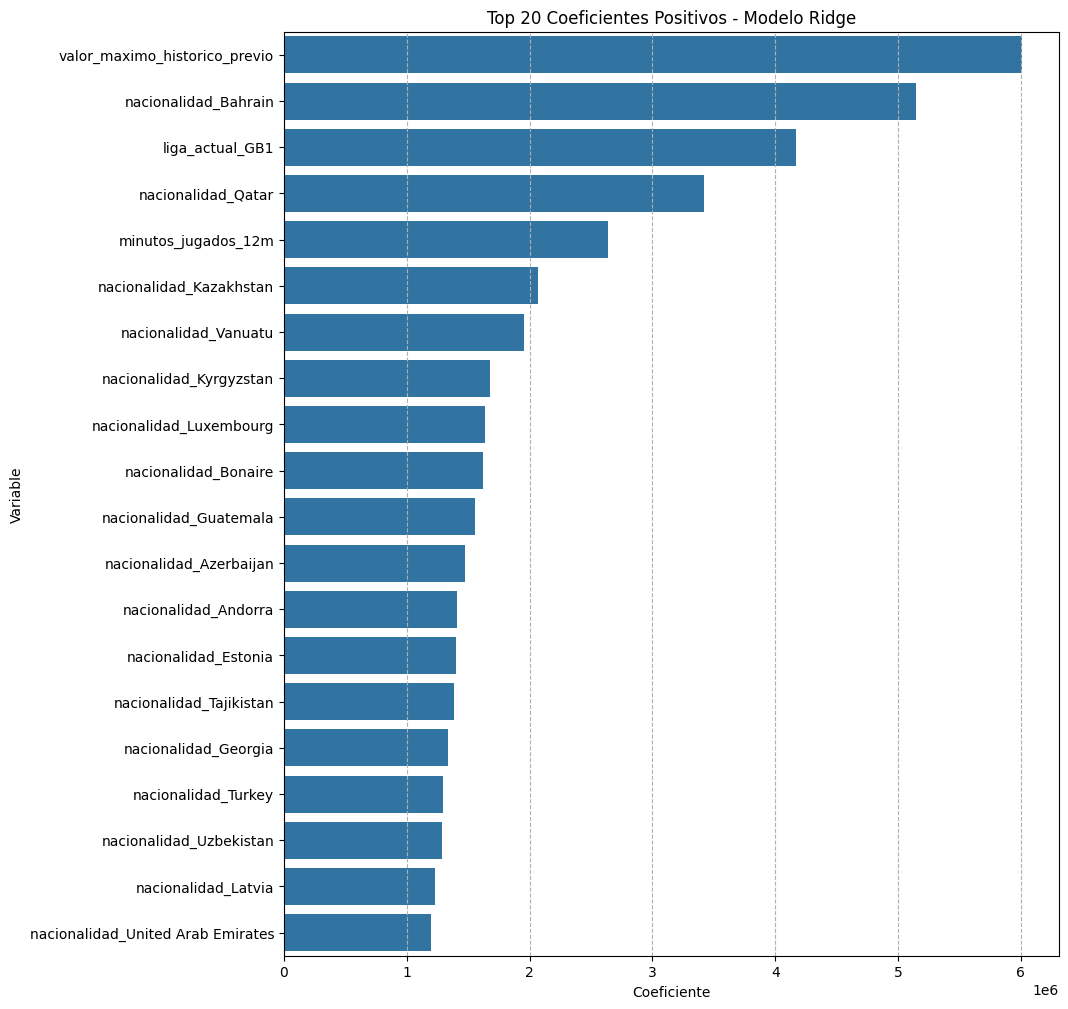

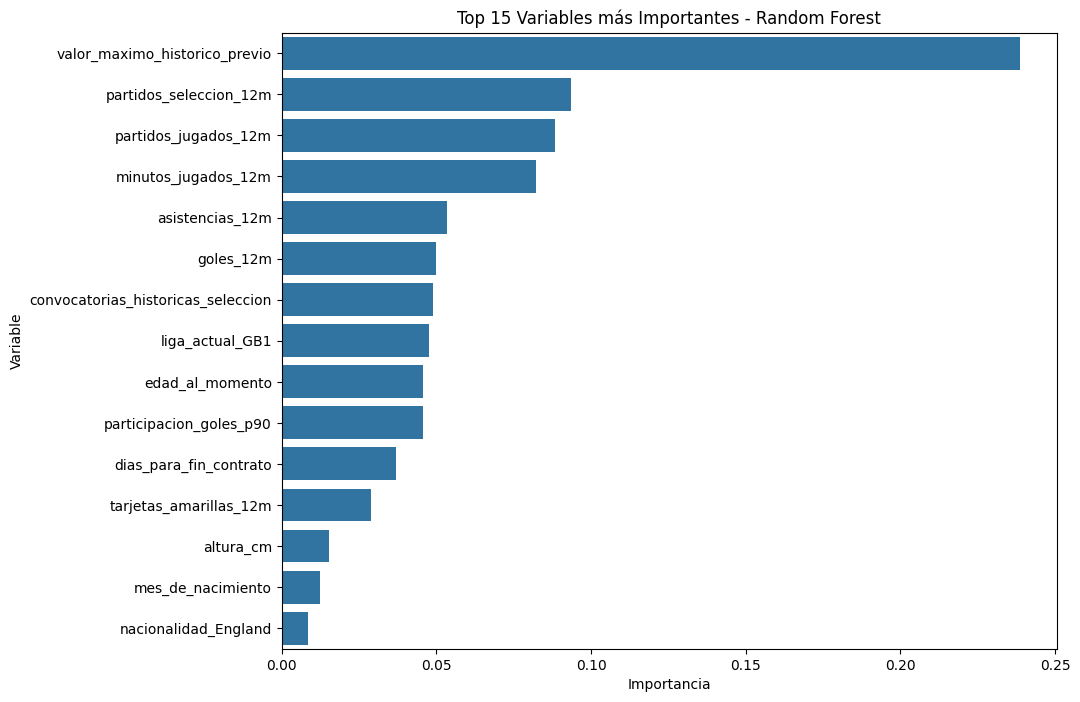

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 8. Interpretabilidad de los Modelos
# ==============================================================================

# 1. Extraer nombres de columnas del preprocesador
# Es vital porque el OneHotEncoder creó columnas nuevas (ej. liga_actual_Premier League)
cat_feature_names = mejor_rf.named_steps['preprocessor'].transformers_[1][1]\
                   .named_steps['onehot'].get_feature_names_out(cat_cols)
all_features = np.concatenate([num_cols, cat_feature_names])

# ---------------------------------------------------------
# a. Modelo Lineal (Ridge): Interpretación de Coeficientes
# ---------------------------------------------------------
coefs = mejor_ridge.named_steps['regressor'].coef_
df_coefs = pd.DataFrame({'Variable': all_features, 'Coeficiente': coefs})
df_coefs = df_coefs.sort_values(by='Coeficiente', ascending=False)

plt.figure(figsize=(10, 12))
sns.barplot(x='Coeficiente', y='Variable', data=df_coefs.head(20)) # Top 20 positivos
plt.title('Top 20 Coeficientes Positivos - Modelo Ridge')
plt.grid(axis='x', linestyle='--')
plt.show()

# ---------------------------------------------------------
# b. Modelo de Árboles (RF): Importancia de Variables
# ---------------------------------------------------------
importances = mejor_rf.named_steps['regressor'].feature_importances_
df_importances = pd.DataFrame({'Variable': all_features, 'Importancia': importances})
df_importances = df_importances.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Variable', data=df_importances.head(15))
plt.title('Top 15 Variables más Importantes - Random Forest')
plt.show()

Generando análisis de residuos para Random Forest en el conjunto de prueba...


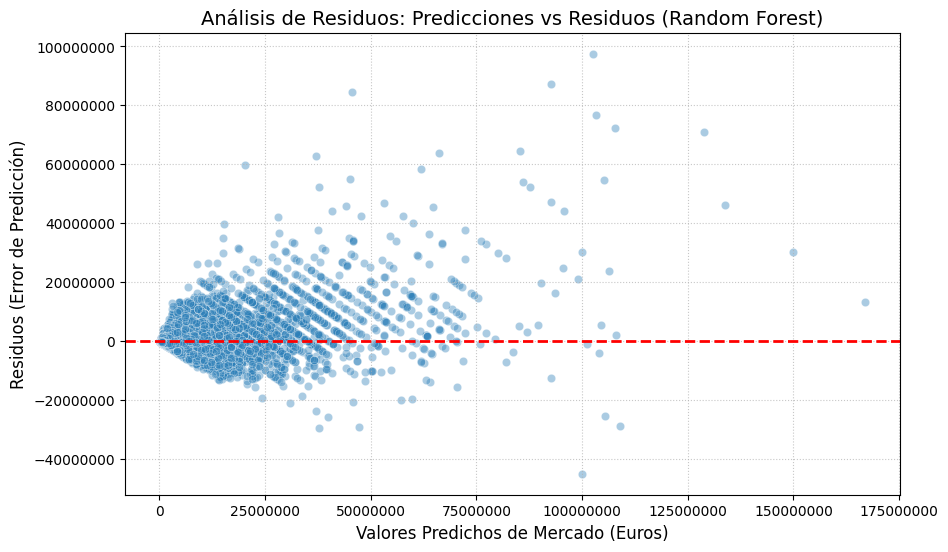

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 9. Análisis de Residuos (Modelo Random Forest)
# ==============================================================================
print("Generando análisis de residuos para Random Forest en el conjunto de prueba...")

# 1. Calculamos las predicciones y los residuos en X_test
predicciones_rf = mejor_rf.predict(X_test)
residuos_rf = y_test - predicciones_rf

# 2. Creamos el gráfico de Residuos vs Predicciones
plt.figure(figsize=(10, 6))
sns.scatterplot(x=predicciones_rf, y=residuos_rf, alpha=0.4, color='#2c7fb8')

# Añadimos la línea del cero (donde el error es nulo, la predicción es perfecta)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Análisis de Residuos: Predicciones vs Residuos (Random Forest)', fontsize=14)
plt.xlabel('Valores Predichos de Mercado (Euros)', fontsize=12)
plt.ylabel('Residuos (Error de Predicción)', fontsize=12)

# Formatear ejes para que no salgan en notación científica (opcional, para que se vea más pro)
plt.ticklabel_format(style='plain', axis='both')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [8]:
import joblib
import os

# ==============================================================================
# 11. Guardado del Modelo Final y sus Características
# ==============================================================================
print("Guardando el modelo Random Forest y las características en la carpeta 'models/'...")

# 1. Definimos la ruta relativa (subimos un nivel desde 'notebooks' hasta la raíz, y entramos a 'models')
ruta_models = '../models/'

# Verificamos si la carpeta existe (por seguridad, aunque en tu VS Code ya se ve que existe)
if not os.path.exists(ruta_models):
    os.makedirs(ruta_models)

# 2. Guardamos el modelo completo (pipeline ganador)
ruta_modelo_pkl = os.path.join(ruta_models, 'model_regression.joblib')
joblib.dump(mejor_rf, ruta_modelo_pkl)

# 3. Guardamos la lista de características (nombres de las columnas que usamos en el Paso 8)
ruta_features_pkl = os.path.join(ruta_models, 'features_regression.joblib')
joblib.dump(all_features, ruta_features_pkl)

print(f"✅ ¡Éxito! Modelo guardado en: {ruta_modelo_pkl}")
print(f"✅ ¡Éxito! Características guardadas en: {ruta_features_pkl}")

Guardando el modelo Random Forest y las características en la carpeta 'models/'...
✅ ¡Éxito! Modelo guardado en: ../models/model_regression.joblib
✅ ¡Éxito! Características guardadas en: ../models/features_regression.joblib
